# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [2]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [4]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:
# cantidad de nulos para users
print(f'Nulos son:\n{users.isna().sum()}')
print(f'\nProporcion de nulos:\n{users.isna().mean()}')

Nulos son:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporcion de nulos:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [12]:
# cantidad de nulos para usage
print(f'Nulos son:\n{usage.isna().sum()}')
print(f'\nProporcion de nulos:\n{usage.isna().mean()}')

Nulos son:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporcion de nulos:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?


Las columnas con valores faltantes para el df `users` son:
- `city` con 11%
- `churn_date` con 88%

- Se recomienda investigar por que la columna `city` tiene un porcentaje de nulos considerable y decidir si se pueden eliminar o imputar.

- Se recomienda ignorar o eliminar la columna `churn_date` debido al alto porcentaje de nulos.

Las columnas con valores faltantes para el df `usage` son:
- `date` con 0.125%.
- `duration` con 55%.
- `length` con 44%.

- Se recomienda imputar la columna `date` ya que el bajo porcentaje de nulos no va a alterar el analisis.
- Se recomienda investigar por que las columnas `duration` y `length` tienen un alto porcentaje de nulos.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [13]:
users['user_id'].describe()

count     4000.000000
mean     11999.500000
std       1154.844867
min      10000.000000
25%      10999.750000
50%      11999.500000
75%      12999.250000
max      13999.000000
Name: user_id, dtype: float64

In [14]:
# explorar columnas numéricas de users
users['age'].describe()

count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

- La columna `user_id` no presenta anomalias
- La columna `age` tiene un valor min de -999 que no tiene sentido y esta sesgando la desviacion estandard (123). 

In [15]:
# explorar columnas numéricas de usage
usage['id'].describe()

count    40000.00000
mean     20000.50000
std      11547.14972
min          1.00000
25%      10000.75000
50%      20000.50000
75%      30000.25000
max      40000.00000
Name: id, dtype: float64

In [16]:
# explorar columnas numéricas de usage
usage['user_id'].describe()

count    40000.000000
mean     12002.405975
std       1157.279564
min      10000.000000
25%      10996.000000
50%      12013.000000
75%      13005.000000
max      13999.000000
Name: user_id, dtype: float64

In [17]:
usage['duration'].describe()

count    17924.000000
mean         5.202237
std          6.842701
min          0.000000
25%          1.437500
50%          3.500000
75%          6.990000
max        120.000000
Name: duration, dtype: float64

In [18]:
usage['length'].describe()

count    22104.000000
mean        52.127398
std         56.611183
min          0.000000
25%         37.000000
50%         50.000000
75%         64.000000
max       1490.000000
Name: length, dtype: float64

- Las columnas `id`, `user_id` y `duration` no presentan anomalias
- La columna `length` tiene una desviacion estandar de 56, lo cual indica sesgo en la distribucion de los datos. Esto se ve reflejado en la diferencia entre el min y max.

In [19]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` solo tiene 3531 filas, lo cual indica valores nulos. Se debe investigar si se pueden imputar.
- La columna `plan` el plan `Basico` es el mas frecuente entre los usuarios.

In [20]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` el tipo de uso mas frecuente es `text`

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  


* ¿En qué columnas encontraste valores inválidos o sentinels?  
* En la columna `age` se detectaron *sentinels*, mientras que en la columna `city` se identificaron valores faltantes (`NaN`).

* ¿Qué acción tomarías?  
* **Para `age`:** Eliminar los registros con valores *sentinels* (o reemplazarlos por `NaN` según el caso).
* **Para `city`:** Imputar los valores faltantes utilizando la moda o una categoría de "Desconocido" o "NA".

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [21]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [22]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [23]:
# Revisar los años presentes en `reg_date` de users
users_unique_years = users['reg_date'].dt.year.unique()
print(f'The number of unique years in reg_date col in users df is: {users_unique_years}')

The number of unique years in reg_date col in users df is: [2022 2026 2023 2024]


En `reg_date`, se cambio el tipo de dato de `object` a `datetime64` para poder hacer operaciones en esta columna.

Tambien, se encuentra en ano 2026 presente en esta columna. Teniendo en cuenta que este dataset solo contiene fechas hasta el ano 2024, podemos concluir que 2026 esta fuera de rango.

In [24]:

# Revisar los años presentes en `date` de usage
usage_unique_year = usage['date'].dt.year.unique()
print(f'the unique years in usage df is: {usage_unique_year}')


the unique years in usage df is: [2024.   nan]


En `date`, se cambio el tipo de dato de `object` a `datetime64`. 
Tambien, se encontro el valor (`nan`), lo cual indica un error de captura o valores nulos (teniendo en cuenta que `date` tiene un 0.125% de valores nulos).

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
En la columna `reg_date` aparece el ano 2026, lo cual esta fuera de rango (> 2024).

- ¿Qué harías con ellas?
Se deberian imputar las filas que tiene anos > 2024.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [25]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()
#print(users['age'].isna().sum())

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [26]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', 'NA')
users['city'] = users['city'].fillna('NA')

# Verificar cambios
users['city'].describe()

count       4000
unique         7
top       Bogotá
freq         808
Name: city, dtype: object

In [27]:
# Marcar fechas futuras como NA para reg_date
# 'Fechas futuras' > 2024?
#users['reg_date'] = np.where(users['reg_date'].dt.year > 2024, pd.NaT, users['reg_date'])
#users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

anos_deps_24 = (users['reg_date'].dt.year > 2024).sum()
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print(f'Cantidad de anos > 2024 en df users es: {anos_deps_24}')
print(f"Cantidad de anos > 2024 despues de imputar es: {(users['reg_date'].dt.year > 2024).sum()}")


Cantidad de anos > 2024 en df users es: 40
Cantidad de anos > 2024 despues de imputar es: 0


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [28]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [29]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquí y escribe que tu diagnostico de nulos en `duration` y `length`

Teniendo en cuenta que el 99% de los valores de la columna `duration` son nulos cuando `type == 'text'` eso indica que estos nulos NO son MAR, sino estructurales.

La misma conclusion aplica para la columna `length`; cuando `type == 'call'` el 99% de los valores nulos para `length` 

Esto hace sentido ya que un mensaje de texto no tiene una duracion en mins y una llamada de texto no tiene un tamana en characteres.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [30]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',      
    'is_call': 'sum',      
    'duration': 'sum'})\
    .reset_index()

# observar resultado
print(usage_agg.head(3))

   user_id  is_text  is_call  duration
0    10000        7        3     23.70
1    10001        5       10     33.18
2    10002        5        2     10.74


In [31]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
        'is_text': 'cant_mensajes', 
        'is_call': 'cant_llamadas', 
        'duration': 'cant_minutos_llamadas'})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamadas
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [32]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamadas
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [33]:
# Resumen estadístico de las columnas numéricas
num_cols = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamadas']
up_mean = user_profile[num_cols].mean()
up_median = user_profile[num_cols].median()
up_std = user_profile[num_cols].std()
up_min = user_profile[num_cols].min()
up_max = user_profile[num_cols].max()


print(f'La media es:\n{up_mean}')
print(f'\nLa mediana es:\n{up_median}')
print(f'\nLa desviacion estandar es:\n{up_std}')
print(f'\nEl minimo es:\n{up_min}')
print(f'\nEl maximo es:\n{up_max}')


La media es:
age                      48.122250
cant_mensajes             5.524381
cant_llamadas             4.478120
cant_minutos_llamadas    23.317054
dtype: float64

La mediana es:
age                      47.00
cant_mensajes             5.00
cant_llamadas             4.00
cant_minutos_llamadas    19.78
dtype: float64

La desviacion estandar es:
age                      17.690408
cant_mensajes             2.358416
cant_llamadas             2.144238
cant_minutos_llamadas    18.168095
dtype: float64

El minimo es:
age                      18.0
cant_mensajes             0.0
cant_llamadas             0.0
cant_minutos_llamadas     0.0
dtype: float64

El maximo es:
age                       79.00
cant_mensajes             17.00
cant_llamadas             15.00
cant_minutos_llamadas    155.69
dtype: float64


In [34]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

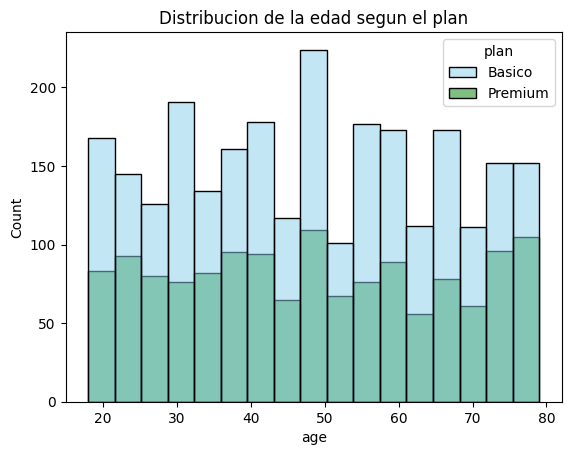

In [71]:
#print(user_profile.groupby('age')['plan'].agg(['count']).reset_index())

# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribucion de la edad segun el plan')
plt.show()


💡Insights: 
- El pico con el mayor porcentajde de clientes entre basico y premium esta en el rango de edad de 40-50
- El 64% de los usuarios esa el plan basico.

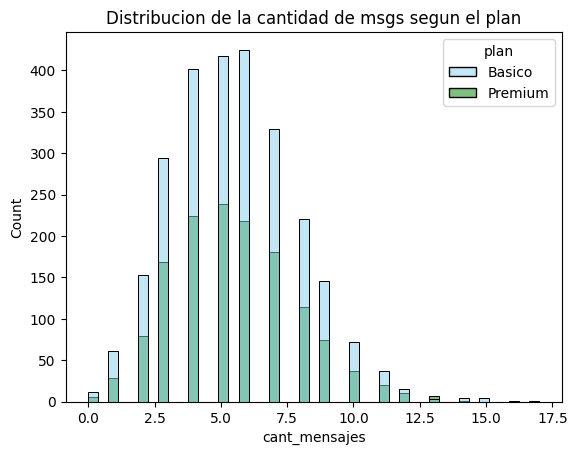

La media de usuarios basicos que envian mas de 10 msgs es: 2.47
La media de usuarios premium que envian mas de 10 msgs es: 2.78


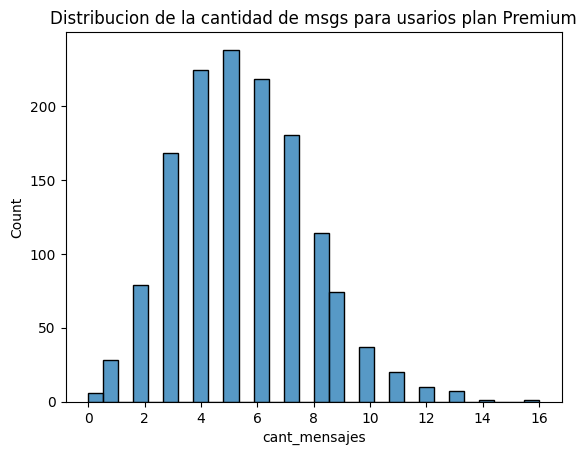

In [90]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribucion de la cantidad de msgs segun el plan')
plt.show()

cols_interes = ['plan', 'user_id', 'cant_llamadas', 'cant_mensajes', 'cant_minutos_llamadas']

# Usuarios con plan basico
basic_users = user_profile[cols_interes]
basic_users = basic_users[basic_users['plan'] == 'Basico']
median_basi_user = (basic_users['cant_mensajes'] > 10).mean() * 100
print(f"La media de usuarios basicos que envian mas de 10 msgs es: {median_basi_user:.2f}")

# usuarios con plan premium
premium_users = user_profile[cols_interes]
premium_users = premium_users[premium_users['plan'] == 'Premium']
median_prem_user = (premium_users['cant_mensajes'] > 10).mean() * 100
print(f"La media de usuarios premium que envian mas de 10 msgs es: {median_prem_user:.2f}")


sns.histplot(data=premium_users, x='cant_mensajes')
plt.title('Distribucion de la cantidad de msgs para usarios plan Premium')
plt.show()



💡Insights: 
- La mayoria de los usuarios envian entre 2.5 y 10 mensajes, entre el plan basico y premium.
- La distribucion esta sesgada a la derecha lo que indica que unos pocos usuarios envian > 10 mensajes.

In [73]:
basic_user = user_profile[user_profile['plan'] == 'Basico']
# basic_user = basic_user['cant_llamadas'].value_counts(normalize=True)
(basic_user['cant_llamadas'] > 7).mean()


0.08323699421965318

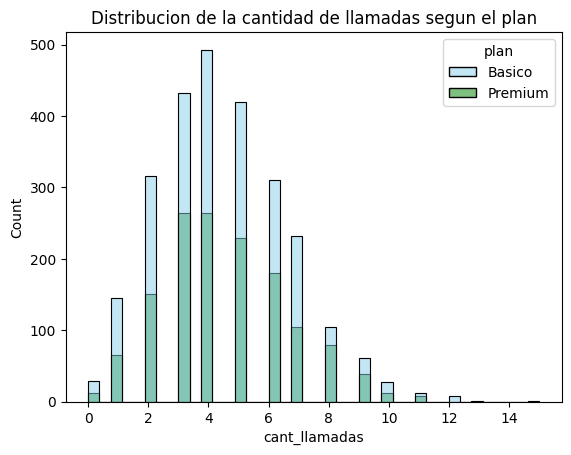

La media de usuarios basico que hacen mas de 10 llamadas es: 0.85
La media de usuarios premium que hacen mas de 10 llamadas es: 0.57


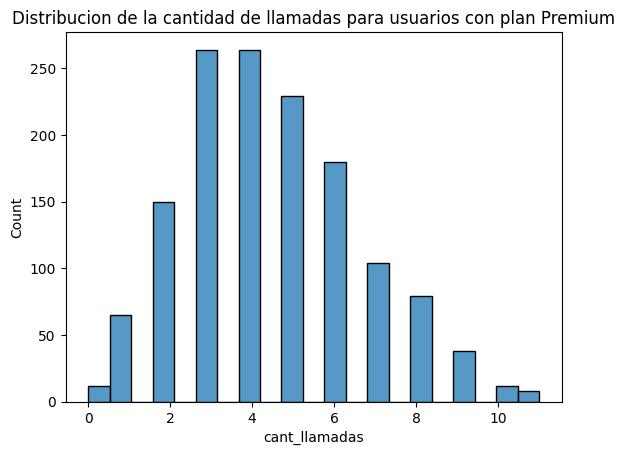

In [81]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribucion de la cantidad de llamadas segun el plan')
plt.show()

#stuff = premium_users[premium_users['cant_llamadas'] > 7]
#print(stuff.groupby('cant_llamadas').agg(['count']))


# Usuarios con plan basico
cal_median_basi_user = (basic_users['cant_llamadas'] > 10).mean() * 100
print(f"La media de usuarios basico que hacen mas de 10 llamadas es: {cal_median_basi_user:.2f}")

# usuarios con plan premium
cal_median_prem_user = (premium_users['cant_llamadas'] > 10).mean() * 100
print(f"La media de usuarios premium que hacen mas de 10 llamadas es: {cal_median_prem_user:.2f}")



sns.histplot(data=premium_users, x='cant_llamadas')
plt.title('Distribucion de la cantidad de llamadas para usuarios con plan Premium')
plt.show()


💡Insights: 
- La mayoria de los usuarios hacen entre 2 y 10 llamadas.
- Unos pocos hacen > 10 llamdas. La distribucion esta levemente sesgada hacia la derecha.

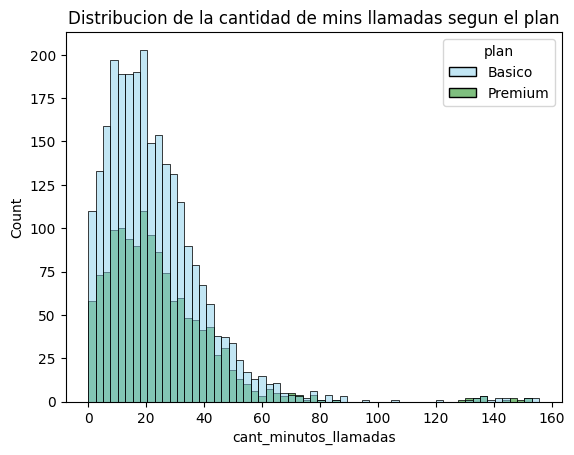

La media de usuarios basico que sostienen llamadas > 80 mins es: 1.04
La media de usuarios premium que sostienen llamadas > 80 mins es: 1.07


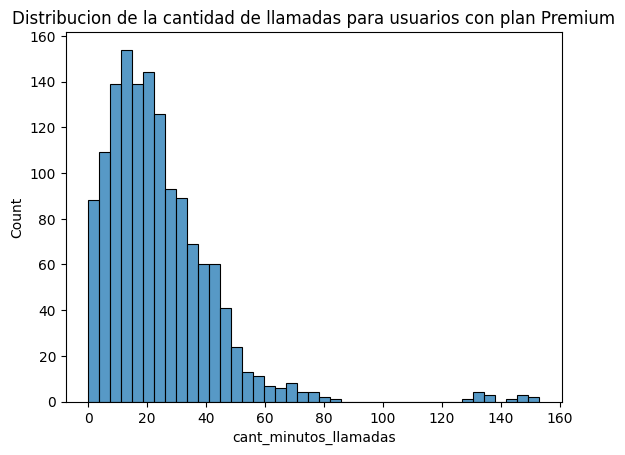

In [83]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamadas', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribucion de la cantidad de mins llamadas segun el plan')
plt.show()

# Usuarios con plan basico
mins_median_basi_user = (basic_users['cant_minutos_llamadas'] > 80).mean() * 100
print(f"La media de usuarios basico que sostienen llamadas > 80 mins es: {mins_median_basi_user:.2f}")

# usuarios con plan premium
mins_median_prem_user = (premium_users['cant_minutos_llamadas'] > 80).mean() * 100
print(f"La media de usuarios premium que sostienen llamadas > 80 mins es: {mins_median_prem_user:.2f}")


sns.histplot(data=premium_users, x='cant_minutos_llamadas')
plt.title('Distribucion de la cantidad de llamadas para usuarios con plan Premium')
plt.show()


💡Insights: 
- La mayoria de los usuarios sostienen llamadas de entre 0-80 mins de duracion entre el plan basico y premium.
- La distribucion esta sesgada a la derecha lo que indica que unos pocos usuarios (outliers) sostienen llamadas > 80 mins.


### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

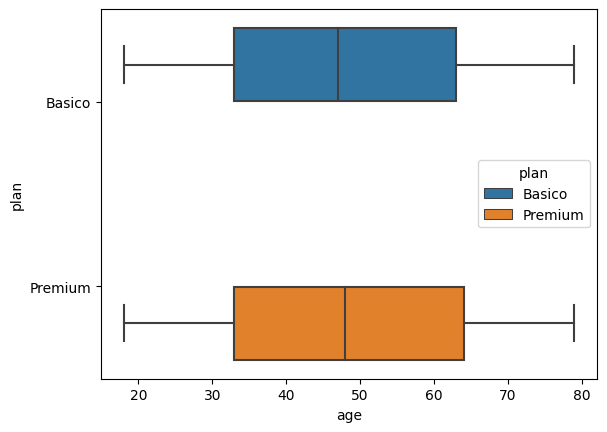

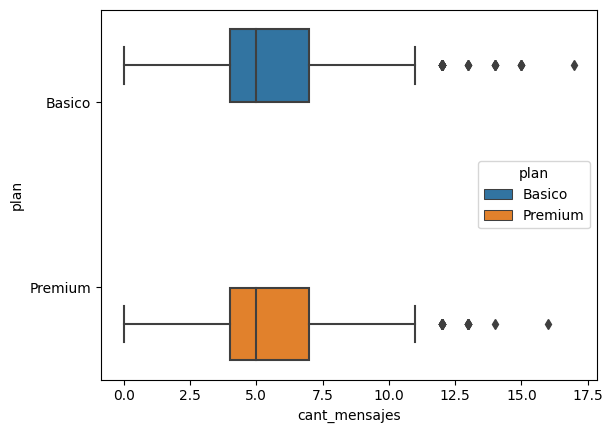

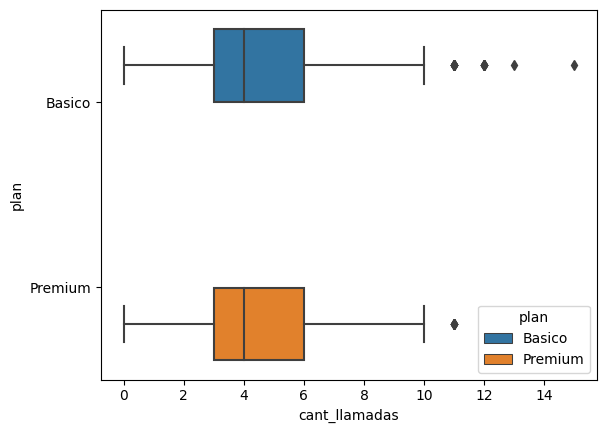

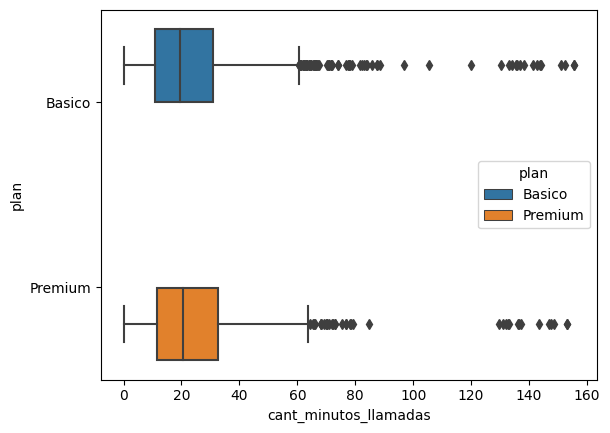

In [39]:
# Visualizando usando BoxPlot 
num_cols = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamadas']
#sns.boxplot(data=user_profile, x='cant_minutos_llamadas', y='plan', hue='plan')
#plt.show()

for num_cols in user_profile[num_cols]:
    sns.boxplot(data=user_profile, x=num_cols, y='plan', hue='plan')
    plt.show()

💡Insights: 
- **Age:** No presenta outliers
- **cant_mensajes:** Si presenta varios outliers 
- **cant_llamadas:** Si presenta varios outliers
- **cant_minutos_llamada:** Es la columna con mayor cantidad de outliers segun el metodo IQR

In [89]:
# Calcular límites con el método IQR
col_lim = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamadas']

for col in user_profile[col_lim]:

    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    
    outlier_mask = (user_profile[col] < lower_bound) | (user_profile[col] > upper_bound)
    outliers = user_profile[outlier_mask]
    
    print(f"For column {col}:")
    print(f"Boundaries: [{lower_bound:.2f} to {upper_bound:.2f}]")
    print(f"Identified {len(outliers)} outliers out of {len(user_profile[col])} records.")

print(((4000 - 3924)/4000) * 100)
print(((109)/4000) * 100)

For column cant_mensajes:
Boundaries: [-0.50 to 11.50]
Identified 46 outliers out of 4000 records.
For column cant_llamadas:
Boundaries: [-1.50 to 10.50]
Identified 30 outliers out of 4000 records.
For column cant_minutos_llamadas:
Boundaries: [-19.32 to 61.86]
Identified 109 outliers out of 4000 records.
1.9
2.725


In [41]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no

iqr_col = ['cant_mensajes', 'cant_llamadas']

user_profile_clean = user_profile.copy()

for col in user_profile[iqr_col]:
    Q1 = user_profile_clean[col].quantile(0.25)
    Q3 = user_profile_clean[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    if lower_bound < 0:
        lower_bound = 0

    user_profile_clean = user_profile_clean[(user_profile_clean[col] >= lower_bound) & (user_profile_clean[col] <= upper_bound)]
    print(f"Original rows: {user_profile[col].shape[0]} for {col} | Cleaned rows: {user_profile_clean[col].shape[0]}")    

# Capping at the 99th percentile (winsorization) for 'cant_minutos_llamadas' instead of deleting
print(f"Original rows for cant_minutos_llamadas {user_profile['cant_minutos_llamadas'].shape[0]}")

upper_limit = user_profile['cant_minutos_llamadas'].quantile(0.99)
user_profile_clean['cant_minutos_llamadas'] = user_profile['cant_minutos_llamadas'].clip(upper=upper_limit)

print(f"Clean rows for cant_minutos_llamadas {user_profile_clean['cant_minutos_llamadas'].shape[0]}")

# user_profile_clean[user_profile_clean['cant_llamadas'] <= user_profile_clean['cant_llamadas'].max()].head()

# user_profile[columnas_limites].describe()

Original rows: 4000 for cant_mensajes | Cleaned rows: 3953
Original rows: 4000 for cant_llamadas | Cleaned rows: 3924
Original rows for cant_minutos_llamadas 4000
Clean rows for cant_minutos_llamadas 3924


💡Insights: 
- **Para `cant_mensajes`**: No se mantendran los outliers ya que solo son 46 de 4000 filas, lo cual representa solo el 1.15% del total del dataset. Se eliminaran usando el metodo IQR.
- **Para `cant_llamadas`**: No se mantendran los outliers ya que solo son 30 de 4000 filas, lo cual representa solo el 0.75% del total del dataset. Se eliminaran usando el metodo IQR.
- **Para `cant_minutos_llamada`**: No se mantendran los outliers, sin embargo, en lugar de usar el metodo IQR (que arroja 109 filas - 2.7%), se utilizo winsorization haciendo un cap en el percentil 99 (que arrojo 76 - 1.9%), para minimizar el riesgo de perder informacion.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [99]:


# Crear columna grupo_uso
user_profile_clean['grupo_uso'] = 'Sin clasificar'

# Bajo uso
user_profile_clean.loc[
    (user_profile_clean['cant_llamadas'] < 5) |
    (user_profile_clean['cant_mensajes'] < 5),
    'grupo_uso'
] = 'Bajo uso'

# Medio uso
user_profile_clean.loc[
    (user_profile_clean['cant_llamadas'] >= 5) &
    (user_profile_clean['cant_llamadas'] <= 10) &
    (user_profile_clean['cant_mensajes'] >= 5) &
    (user_profile_clean['cant_mensajes'] <= 10),
    'grupo_uso'
] = 'Medio uso'

# Alto uso
user_profile_clean.loc[
    (user_profile_clean['cant_llamadas'] > 10) |
    (user_profile_clean['cant_mensajes'] > 10),
    'grupo_uso'
] = 'Alto uso'




In [92]:
# verificar cambios
user_profile_clean.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamadas,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Medio uso,Adulto
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Medio uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Medio uso,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Medio uso,Adulto Mayor


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [100]:

# Crear columna grupo_edad
user_profile_clean['grupo_edad'] = 'NA'

user_profile_clean.loc[
    (user_profile_clean['age'] < 30),
    'grupo_edad'
] = 'Joven'

user_profile_clean.loc[
    (user_profile_clean['age'] >= 30) &
    (user_profile_clean['age'] <= 60),
    'grupo_edad'
] = 'Adulto'

user_profile_clean.loc[
    (user_profile_clean['age'] > 60),
    'grupo_edad'
] = 'Adulto Mayor'


In [94]:
# verificar cambios
user_profile_clean.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamadas,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Medio uso,Adulto
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Medio uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Medio uso,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Medio uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

   grupo_uso  count
1   Bajo uso   2754
2  Medio uso   1113
0   Alto uso     57


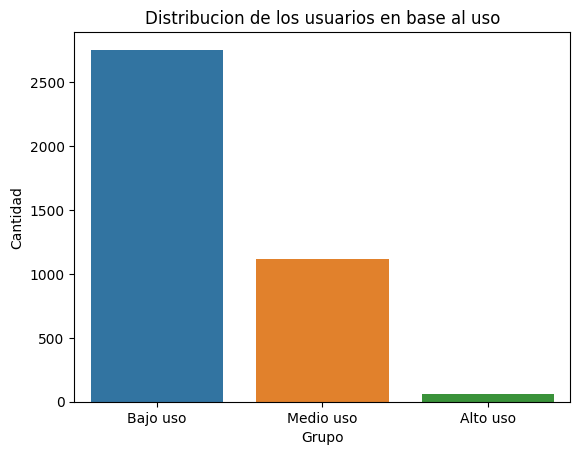

0.01425


In [114]:
# Visualización de los segmentos por uso
grupo_uso_series = user_profile_clean.groupby('grupo_uso')['user_id']\
    .agg(['count'])\
    .reset_index()\
    .sort_values(by='count', ascending=False)

print(grupo_uso_series)

data_grupo_uso = user_profile_clean[['user_id', 'grupo_uso']]

sns.countplot(data=data_grupo_uso, x='grupo_uso')
plt.title('Distribucion de los usuarios en base al uso')
plt.xlabel('Grupo')
plt.ylabel('Cantidad')
plt.show()

print(57/4000)

     grupo_edad  count
0        Adulto   2049
1  Adulto Mayor   1126
2         Joven    749


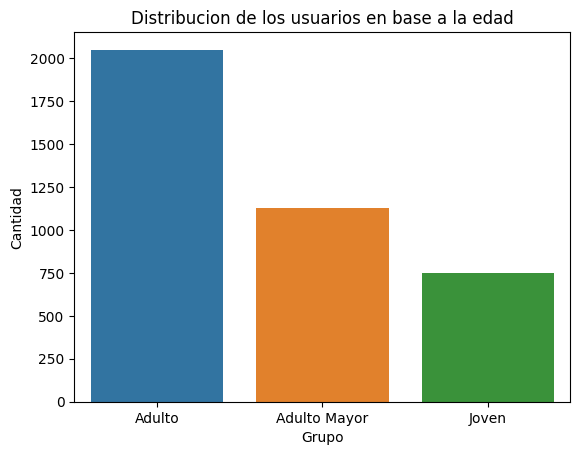

In [101]:
# Visualización de los segmentos por edad
grupo_edad_series = user_profile_clean.groupby('grupo_edad')['user_id']\
    .agg(['count'])\
    .reset_index()\
    .sort_values(by='count', ascending=False)

print(grupo_edad_series)

data_grupo_edad = user_profile_clean[['user_id', 'grupo_edad']]

sns.countplot(data=data_grupo_edad, x='grupo_edad')
plt.title('Distribucion de los usuarios en base a la edad')
plt.xlabel('Grupo')
plt.ylabel('Cantidad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo


⚠️ **Problemas detectados en los datos**
- Las columnas `city` y `age` en el dataset (users) presentaban valores faltantes y sentinels.
- Las columnas `duration` y `length` en el dataset (usage) presentaban valores faltantes estructurales (No MAR) dependiendo del dato de la columna `type`.
- Se limpiaron fechas fuera de rango en el dataset (users), ya que contenia fechas mayores a 2024.



🔍 **Segmentos por Edad**
- El segmento mas grando de clientes es "Adulto" (rango de edad entre 30-60) y el mas pequeno es "Joven" (rango de edad entre 0-30 anos)
- La adopción de Premium es uniforme entre todos los segmentos de edad (~35%).


📊 **Segmentos por Nivel de Uso**
- La mayoria de los usuarios (el 70%) tienen un bajo uso de mensajes y llamadas.
- Solo el 1.5% de los usuarios, en ambos planes (Basico y Premium), tienen un alto uso de mensajes y llamadas.
- Y el 28% de los usuarios tienen un uso medio de mensajes y llamadas. 


➡️ Esto sugiere que la cantidad de mensajes y llamadas que se ofrecen en el plan, no es un factor diferenciador para los clientes al momento de elegir usar el plan Premium o Basico.


💡 **Recomendaciones**
- ConnectaTel debería considerar ofrecer planes diferenciados por "gb_per_month"
- La estrategia de marketing no deberia enfocarse en un rango de edad en especifico.
- Para los usuarios de alto uso (1.5%) que usan el plan Basico, deberian ser ayudados, via descuentos o promociones, a moverse al plan premium.


In [115]:
#user_profile_clean.groupby(['grupo_edad', 'plan'])['user_id'].agg(['count']).sort_values(by='plan', ascending=False)

porcentaje_edad = pd.crosstab(
    user_profile_clean['grupo_edad'],
    user_profile_clean['plan'],
    normalize='index'
).round(3) * 100

print(porcentaje_edad)

porcentaje_uso = pd.crosstab(
    user_profile_clean['plan'],
    user_profile_clean['grupo_uso'],
    normalize='index'
).round(3) * 100

print()
print(porcentaje_uso)

plan          Basico  Premium
grupo_edad                   
Adulto          65.5     34.5
Adulto Mayor    64.2     35.8
Joven           64.1     35.9

grupo_uso  Alto uso  Bajo uso  Medio uso
plan                                    
Basico          1.5      70.0       28.5
Premium         1.5      70.5       28.1


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`

In [ ]:
https://github.com/jesusmayo09/connectatel-analysis